In [1]:
import os
import numpy as np
import pandas as pd
import mplhep as hep
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

#os.chdir('..')

#from parameters import PtBinning, AK8TaggerWP
from parameters import AK8TaggerWP, AK8Taggers, AK8Taggers_bb, AK8Taggers_cc

PtBinning = {
    '2016_PreVFP' : {
        '450to500' : (450, 500),
        '500to600' : (500, 600),
        '600toInf' : (600, 'Inf'),
    },
    '2016_PostVFP' : {
        '450to500' : (450, 500),
        '500to600' : (500, 600),
        '600toInf' : (600, 'Inf'),
    },
    '2017' : {
        '450to500' : (450, 500),
        '500to600' : (500, 600),
        '600toInf' : (600, 'Inf'),
    },
    '2018' : {
        '450to500' : (450, 500),
        '500to600' : (500, 600),
        '600toInf' : (600, 'Inf'),
    }
}


hep.style.use(hep.style.ROOT) # For now ROOT defaults to CMS

In [4]:
folders = {
    '2018' : "/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2018/fit_inclusive_all_renormalized",
    #'2017' : "/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2017/fit_inclusive_all_results"
}
fontsize = 16
colors = {
    'L' : 'green',
    'M' : 'red',
    'H' : 'blue',
}
offset = {
    'L' : +0.1, #25,
    'M' : 0,
    'H' : -0.1, #-25,
}
xticks = {0 : "[450, 500)", 1 : "[500, 600)", 2 : "[600, Inf)"}
xlim = (-0.5, 2.5)

btagDDBvLV2
2018 L wp, 450to500 pt
['600toInf', '500to600', '450to500'] [0.86372684 0.86615283 0.94970707]
2018 M wp, 450to500 pt
['500to600', '600toInf', '450to500'] [0.84386068 0.95910507 0.88052697]
2018 H wp, 450to500 pt
['500to600', '600toInf', '450to500'] [0.77196439 0.90855748 0.79768296]


/tmp/ipykernel_15318/2949150382.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_wp = df_wp[((df['pt'] != '400toInf') & (df['pt'] != '600to800')  & (df['pt'] != '800toInf'))]


btagDDCvLV2
2018 L wp, 500to600 pt
['450to500', '600toInf', '500to600'] [0.65240056 0.65148072 0.6508112 ]
2018 M wp, 500to600 pt
['450to500', '600toInf', '500to600'] [0.57944233 0.5        0.73446981]
2018 H wp, 500to600 pt
['450to500', '600toInf', '500to600'] [0.50000184 0.50000033 0.5485272 ]
particleNetMD_Xbb_QCD
2018 L wp, 500to600 pt
['600toInf', '450to500', '500to600'] [1.04942077 1.02033848 0.95299601]
2018 M wp, 450to500 pt
['600toInf', '500to600', '450to500'] [1.03449359 0.92645723 0.94441389]
2018 H wp, 600toInf pt
['450to500', '500to600', '600toInf'] [0.95074289 0.91349897 1.00532639]
particleNetMD_Xcc_QCD
2018 L wp, 500to600 pt
['600toInf', '450to500', '500to600'] [0.97159902 0.88433292 0.98502713]
2018 M wp, 600toInf pt
['500to600', '450to500', '600toInf'] [0.86902119 0.7240911  0.7362237 ]
2018 H wp, 450to500 pt
['600toInf', '500to600', '450to500'] [0.52847375 0.79390939 0.64759078]
deepTagMD_ZHbbvsQCD
2018 L wp, 500to600 pt
['450to500', '600toInf', '500to600'] [0.827793

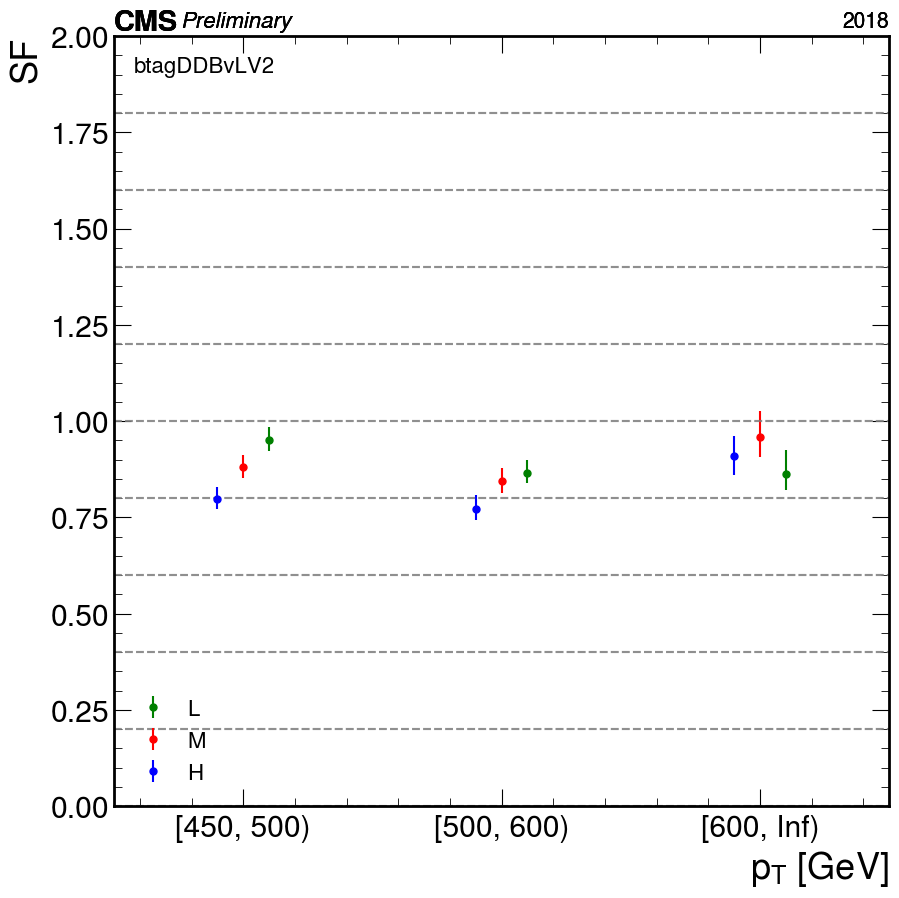

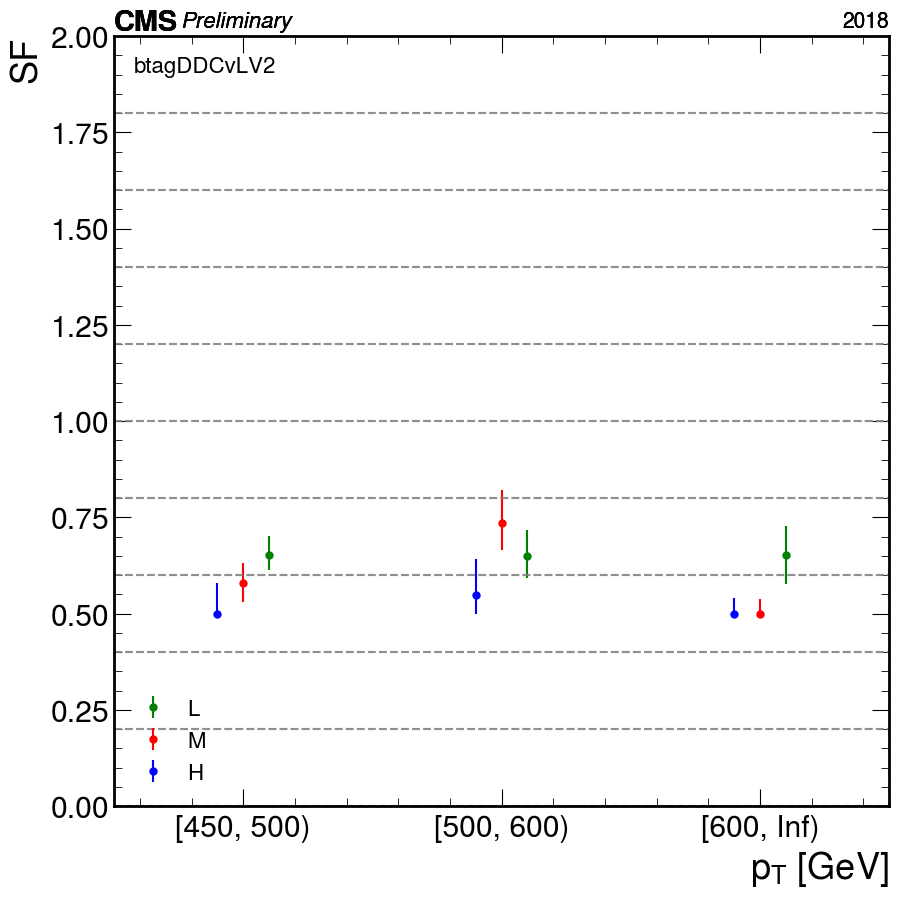

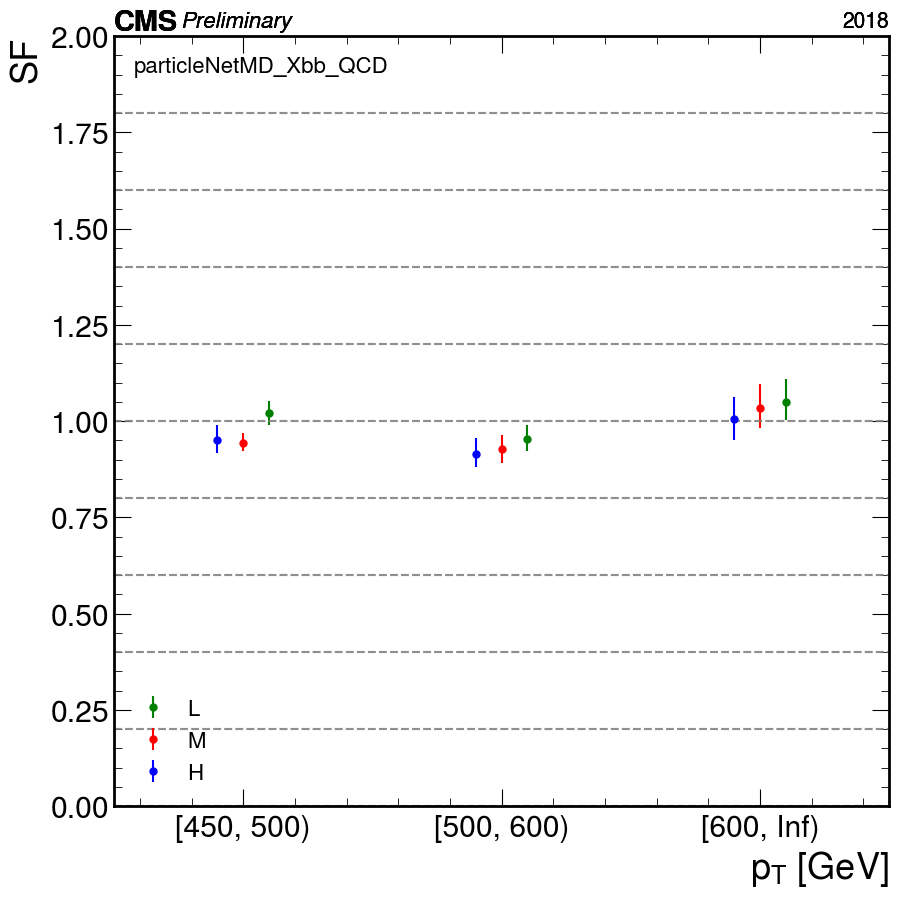

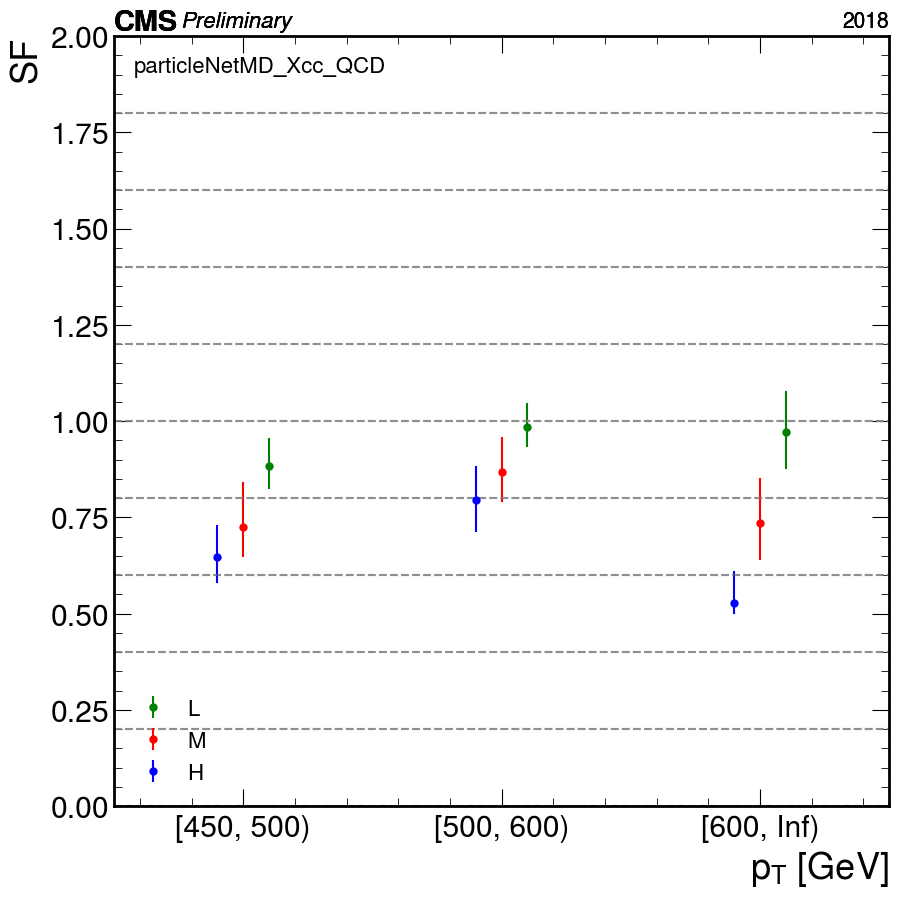

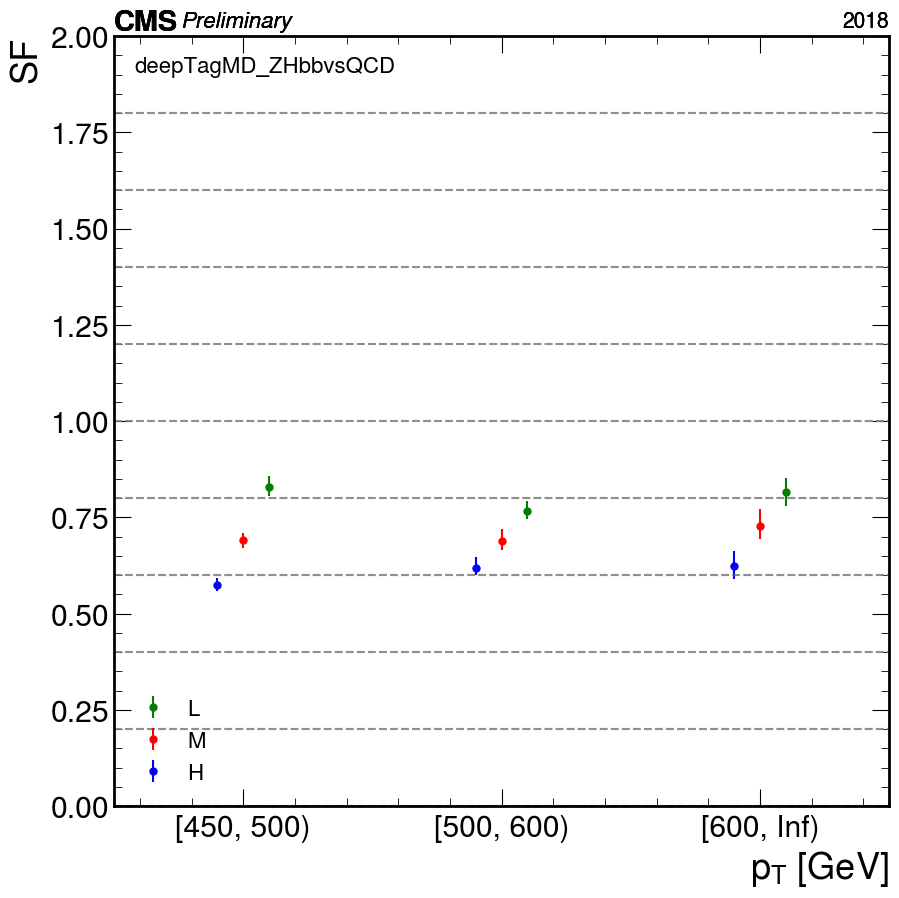

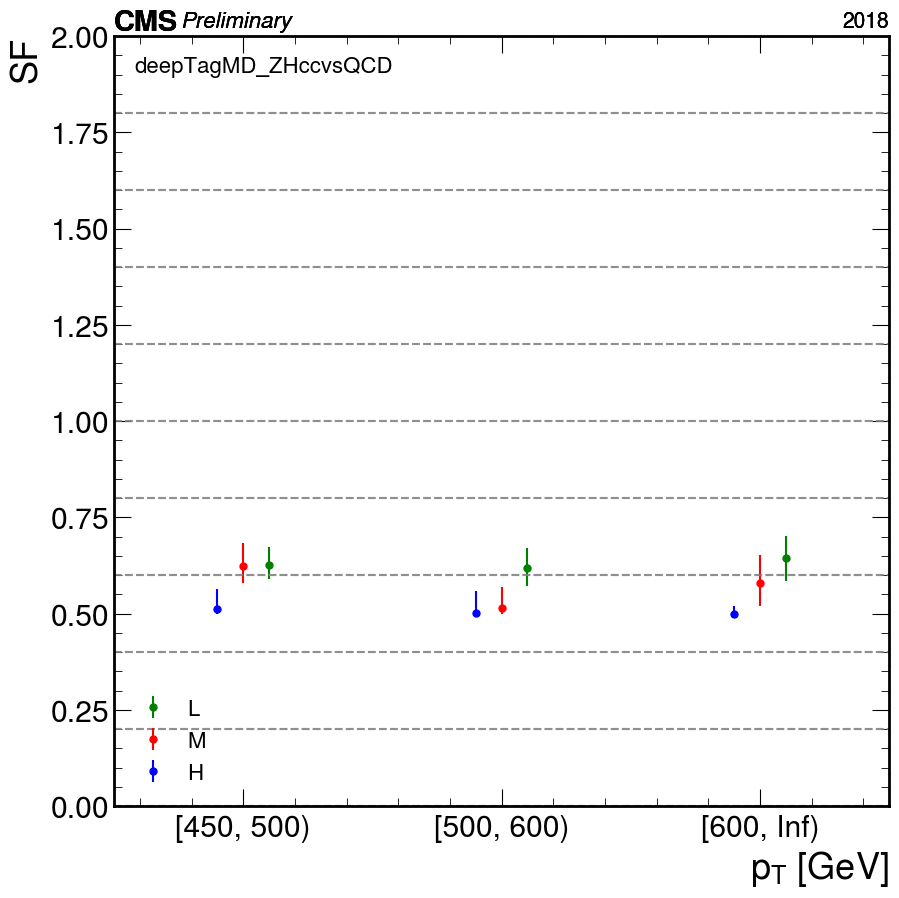

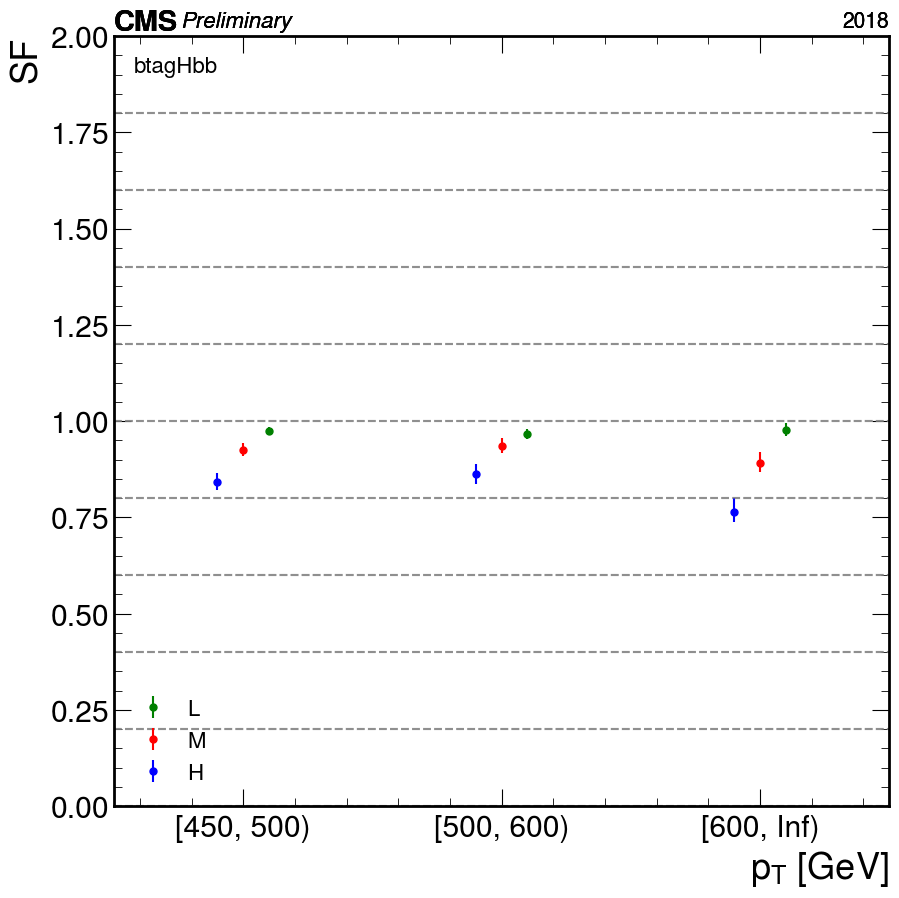

In [5]:
plot_dir_BASE = "230709_results_inclusive_all_renormalized"
results = {year : {} for year in folders.keys()}

for year, folder in folders.items():
    plot_dir = plot_dir_BASE + f'_{year}'
    filename_bb = os.path.join(folder, "fitResults_bb.csv")
    filename_cc = os.path.join(folder, "fitResults_cc.csv")
    # Read the bb and cc dataframes
    df_bb = pd.read_csv(filename_bb)
    df_cc = pd.read_csv(filename_cc)
    # Split the results between bb and cc
    for flavor, df in zip(['bb', 'cc'], [df_bb, df_cc]):
        taggers = [AK8Taggers_bb if flavor == 'bb' else AK8Taggers_cc][0]
        for tagger in taggers:
            mask = [tagger in item for item in df['selection'].values]
            results[year][tagger] = df[mask]
    for i, tagger in enumerate(AK8Taggers):
        fig, ax = plt.subplots(1,1, figsize=[10,10])
        ax.set_xlim(*xlim)
        ax.set_xticks(list(xticks.keys()))
        ax.set_xticklabels(xticks.values())
        ax.set_xlabel(r"p$_T$ [GeV]")
        ax.set_ylabel("SF")
        text = tagger
        at = AnchoredText(text, loc='upper left', prop={'fontsize' : fontsize}, frameon=False)
        ax.add_artist(at)
        print(tagger)
        df = results[year][tagger]
        for wp in [ 'L', 'M', 'H' ]:

            SF = None
            SFerr = None

            if tagger in ['btagDDCvLV2', 'particleNetMD_Xcc_QCD', 'deepTagMD_ZHccvsQCD']:
                POI = 'c+cc'
            elif tagger in ['btagDDBvLV2', 'particleNetMD_Xbb_QCD', 'deepTagMD_ZHbbvsQCD', 'btagHbb']:
                POI = 'b+bb'

            df_wp = df[df['wp'] == wp]
            #df_wp = df_wp[((df['pt'] != '400toInf') & (df['pt'] != '600toInf'))]
            df_wp = df_wp[((df['pt'] != '400toInf') & (df['pt'] != '600to800')  & (df['pt'] != '800toInf'))]
            #df_wp = df_wp[((df['pt'] != '400toInf'))]

            year = str(df_wp['year'].values[0])
            #campaign = df_wp['campaign'].values[0]
            #axes[int(i/2),i%2].set_title(f'{key}', loc='right', fontsize=fontsize)
            hep.cms.text("Preliminary", ax=ax, loc=0, fontsize=fontsize)
            hep.cms.lumitext(year, ax=ax, fontsize=fontsize)
            ptbinning = PtBinning[year]

            SF = df_wp[POI].values
            SFerr = np.array( (df_wp[f'{POI}ErrDown'].values, df_wp[f'{POI}ErrUp'].values) )

            x = []
            pt = []
            #pterr = []
            map_bins = {'450to500' : 0, '500to600' : 1, '600toInf' : 2}
            for wpt in df_wp['pt'].values:
                x.append(map_bins[wpt])
                pt.append(wpt)
                #pt_low, pt_high = ptbinning[wpt]
                #if 'Inf' in wpt:
                #    pt_center = np.mean((pt_low, 1000))
                #else:
                #    pt_center = np.mean((pt_low, pt_high))
                #pt_err = pt_center - pt_low
                #pt.append(pt_center)
                #pterr.append(pt_err)

            #pt = np.array(pt)
            x = np.array(x)

            print(year, f"{wp} wp, {wpt} pt")
            print(pt, SF)


            #axes[int(i/2),i%2].errorbar(pt, SF, xerr=pterr, yerr=SFerr, capsize=8, linestyle='', marker='o', markersize=5, label=wp, color=colors[wp])
            ax.errorbar(x+offset[wp], SF, yerr=SFerr, linestyle='', marker='o', markersize=5, label=wp, color=colors[wp])
            ax.set_ylim(0.0, 2.0)
            #ax.set_xticks([0, 1, 2])
            ax.hlines(np.arange(0, 2.2, 0.2), *xlim, linestyle='dashed', color='gray', alpha=0.5)
        ax.legend(loc="lower left", fontsize=fontsize)
        if not os.path.exists(plot_dir):
            os.makedirs(plot_dir)
        filename = os.path.join(plot_dir, f"sf_results_{tagger}_2018UL_inclusiveWP.png")
        plt.savefig(filename, format="png", dpi=300)

In [12]:
model_name = "msd40btagDDCvLV2passHwpPt-450to500"
any(item in model_name for item in ['btagDDCvLV2', 'particleNetMD_Xcc_QCD', 'deepTagMD_ZHccvsQCD'])

True

In [33]:
ptbinning

{'450to500': (450, 500), '500to600': (500, 600), '600toInf': (600, 'Inf')}